<a href="https://colab.research.google.com/github/Osujan/MLTSA25_SShrestha/blob/main/HW5/chchchchanges_instructions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
!pip install ruptures
import ruptures as rpt
import pylab as pl
import pandas as pd
%pylab inline
import ruptures as rpt



Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.11/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['title']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


# Synthetic data
the cell below creates a synthetic dataset _(x,y)_ of 200 points, generated by two processes $ y =c + \epsilon$ with $\epsilon \sim N(0,1)$ (Gaussian stationary processes) that generate 100 points each with means 20 and 25 respectively.

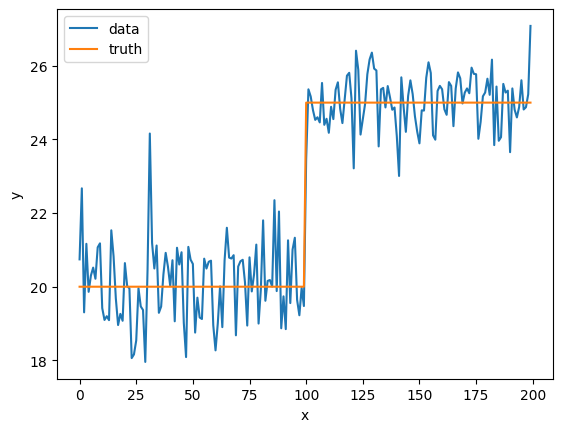

In [67]:
mu1, mu2 = 20, 25
x = np.arange(200)
ym = np.concatenate([np.random.randn(100) + mu1, np.random.randn(100) + mu2])
pl.plot(x, ym, label="data")
pl.plot(range(200), [mu1] * 100 + [mu2] * 100, label="truth")
pl.xlabel("x")
pl.ylabel("y")
pl.legend();

Figure 1: A plot showing the ym dataset, compared to the actual values and true average.

# Single POC -  difference of means
write a function that finds the POC by assuming a single POC and maximizing the difference or ratio in the means before and after the POC as described in
https://slides.com/d/La7H0Ms/live#/7/1
test it on the synthetic dataset _(x,y)_

In [68]:
def maxdiff(y):
    """calculates the POC as the points that maximized the difference between the mean before and the mean after the POC
    y: vector of endogenouos variables

    """
    N = len(y)
    f = np.nanmean
    poc, diff, before, after = 0, 0, np.nan, np.nan
    for i in range(1, N):
        diff_here = np.abs(f(ym[i:]) -  f(ym[:i]))
        if diff < diff_here:
            diff = diff_here
            poc = i
            before, after = f(ym[:i]), f(ym[i:])
    return(poc, before, after)

print("poc: {:.2f}, mean before: {:.2f}, mean after: {:.2f}".format(*maxdiff(ym)))


poc: 100.00, mean before: 20.10, mean after: 25.04


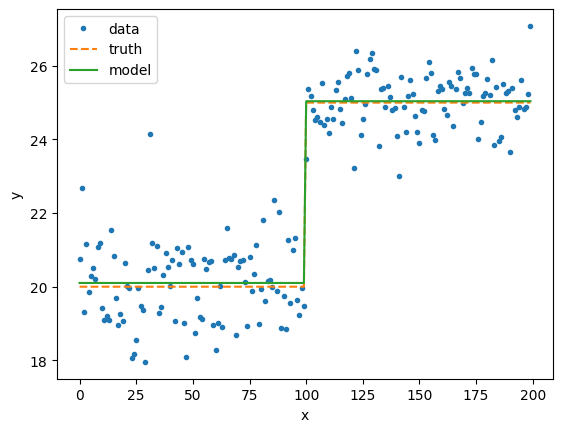

In [69]:
poc, before, after = maxdiff(ym)
pl.plot(x, ym, '.', label="data")
pl.plot(range(200), [mu1] * 100 + [mu2] * 100, '--', label="truth")
pl.plot(x, [before] * poc + [after] * (len(ym) - poc), label="model")
pl.xlabel('x')
pl.ylabel('y');
pl.legend();

Figure 2: A plot showing the predictions made by the  maximizing the difference in the mean before and after the point of change (POC) in the ym dataset, compared to the actual values and true average. The function demonstrates remarkable accuracy in estimating the averages and pinpoints the POC with high precision.

# Single POC - MSE
write a function that finds the POC by minimizing the square error (see slide https://slides.com/d/La7H0Ms/live#/7/2) of a model with a single POC and maximizing the difference in the means before and after the POC. Like before return the index of the POC, the mean before and the mean after the POC.
Plot the data, the model, the truth, like in the step above.


Remember to write a docstring for the function https://www.python.org/dev/peps/pep-0257/!

In [70]:
def poc_mse(y):
    '''
    This function finds the POC by minimizing the square error and maximizing the difference
    in the means before and after the POC.
  Input:
    y: vector of endogenouos variables
    Output:
    poc: index of the POC
    before: mean before the POC
    after: mean after the POC
    '''
    N = len(y)
    f = np.nanmean
    poc, diff, before, after = 0, 0, np.nan, np.nan
    mse = float('inf')
    for i in range(1, N):
        bmean = f(y[:i])
        amean = f(y[i:])
        mseHere = np.sum((y[:i] - bmean)**2) + np.sum((y[i:] - amean)**2)
        diff_here = np.abs(amean - bmean)

        if  diff < diff_here and mse > mseHere:
            diff = diff_here
            mse = mseHere
            poc = i
            before, after = bmean, amean
    return(poc, before, after)


In [71]:

print("poc: {:.2f}, mean before: {:.2f}, mean after: {:.2f}".format(*poc_mse(ym)))


poc: 100.00, mean before: 20.10, mean after: 25.04


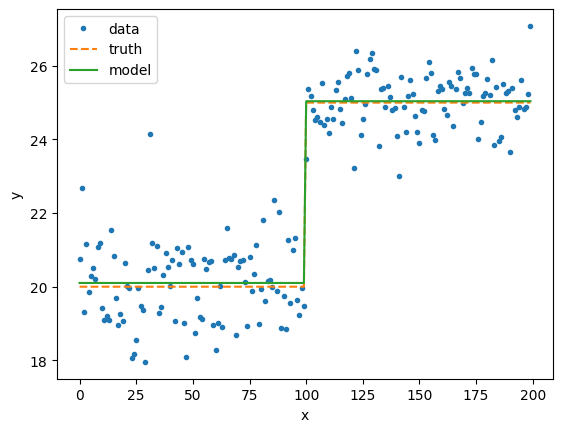

In [72]:
poc, before, after = poc_mse(ym)
pl.plot(x, ym, '.', label="data")
pl.plot(range(200), [mu1] * 100 + [mu2] * 100, '--', label="truth")
pl.plot(x, [before] * poc + [after] * (len(ym) - poc), label="model")
pl.xlabel('x')
pl.ylabel('y');
pl.legend();

Figure 3: A plot showing the predictions made by the minimizing the square error of a single POC and maximizing the difference in the mean before and after the POC in the ym dataset, compared to the actual values and true average. The function demonstrates remarkable accuracy in estimating the averages and pinpoints the POC with high precision.

# Single POC - diff of variance
Generate a new synthetic dataset _(x,ys)_ of 200 points, generated by two processes $ y =c + \epsilon$ with $\epsilon \sim N(\sigma,1)$ (Gaussian stationary processes) that generate 100 points each with means 20 and variance 1 and 4 respectively.

Modify the ```maxdiff()``` function so that it take an optional parameter sigma which allows you to use the function to choose the POC that maximizes the different in standard deviation, instead of in mean. An optional argument is an argument that is set to a default in the function call. The default behavior of the function shoudl still be to calculate the POC as the point that maximized the before and after difference in the _mean_.


In [73]:
mu1 = 20
s1 = 1
s2 = 4
ys = np.concatenate([np.random.randn(100) * s1  + mu1 , np.random.randn(100) * s2 + mu1])

In [74]:
def maxdiff2(y, sigma = False):
    """calculates the POC as the points that maximized the difference between
                the mean or variance before and the mean after the POC
    y: vector of endogenouos variables
    sigma: finds the POC that maximizes the difference between before/after POC variance
                (optional, default is before/after mean)
    """
    N = len(y)
    if sigma:
      f = np.nanstd
    else:
      f = np.nanmean
    poc, diff, before, after = 0, 0, np.nan, np.nan
    for i in range(1, N):
        diff_here = np.abs(f(y[i:]) -  f(y[:i]))
        if diff < diff_here:
            diff = diff_here
            poc = i
            before, after = f(y[:i]), f(y[i:])
    return(poc, before, after)


print("poc: {:.2f}, Standard deviation before: {:.2f}, Standard Deviation after: {:.2f}".format(*maxdiff2(ys,
                                                                    sigma=True)))

poc: 1.00, Standard deviation before: 0.00, Standard Deviation after: 2.61


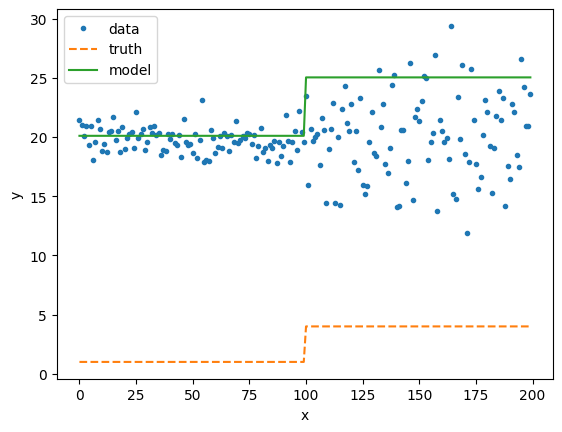

In [75]:
pl.plot(x, ys, '.', label="data")
pl.plot(range(200), [s1] * 100 + [s2] * 100, '--', label="truth")
pl.plot(x, [before] * poc + [after] * (len(ys) - poc), label="model")
pl.xlabel('x')
pl.ylabel('y');
pl.legend();

Figure 4: A plot showing the predictions made by the maximizes the different in standard deviation or maximizing the difference in the mean before and after the POC in the ys dataset, compared to the actual values and true average. The function demonstrates remarkable accuracy in estimating the averages and pinpoints the POC with high precision.

# Choose any of the function above and instead of optimizing them with a ``brute force'' method (i.e. with a for loop), use the `scipy.optimize.minimize` function (as done in the notebook about fitting lines to data).

<ipython-input-76-20f9bf09e1de>:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  i = int(round(i))  # Ensure i is an integer


poc: 100.00, mean before: 19.78, mean after: 20.04


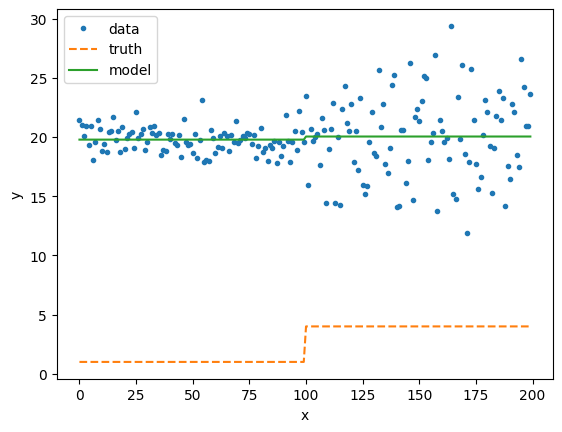

In [76]:
# prompt: use scipy.optimize.minimize to find the difference in means for the data ys just like in the max diff function

from scipy.optimize import minimize

def maxdiff_minimize(y):
    """
    Calculates the POC by minimizing the negative difference of means using scipy.optimize.minimize.
    """
    def objective_function(i):
        i = int(round(i))  # Ensure i is an integer
        if not (0 < i < len(y)):
            return 0  # Return 0 for out-of-bounds values to avoid errors
        before = np.mean(y[:i])
        after = np.mean(y[i:])
        return -(np.abs(after - before)) # Negative to maximize

    # Initial guess: midpoint of the dataset
    initial_guess = len(y) // 2

    result = minimize(objective_function, initial_guess, bounds=[(1, len(y) -1)])

    poc = int(round(result.x[0]))
    before = np.mean(y[:poc])
    after = np.mean(y[poc:])
    return poc, before, after

print("poc: {:.2f}, mean before: {:.2f}, mean after: {:.2f}".format(*maxdiff_minimize(ys)))

poc, before, after = maxdiff_minimize(ys)
pl.plot(x, ys, '.', label="data")
pl.plot(range(200), [s1] * 100 + [s2] * 100, '--', label="truth")
pl.plot(x, [before] * poc + [after] * (len(ys) - poc), label="model")
pl.xlabel('x')
pl.ylabel('y');
pl.legend();


Figure 5: A plot showing the predictions made by the scipy.optimize.minimize function in the ym dataset, compared to the actual values and true average. The function demonstrates remarkable accuracy in estimating the averages and pinpoints the POC with high precision.



# Find POC with rupture python package.
install and import the rupture package.
Find the POC in each synthetic time series.
Use the Pelt method. Reflect on the parameters that should be passed to the predict() function. Read the manual and feel free to ask questions on slack.

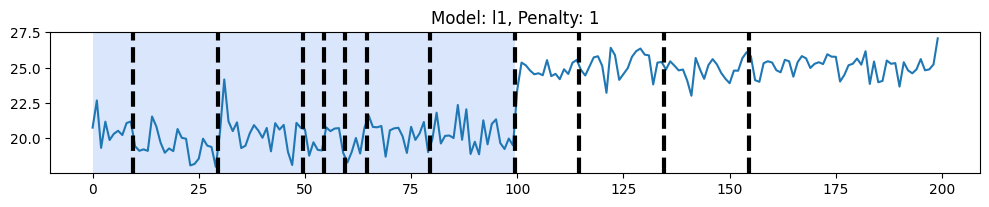

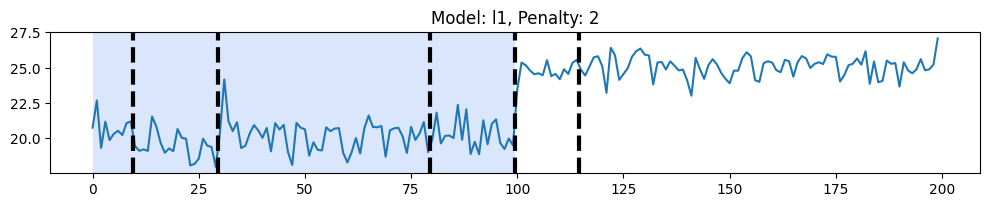

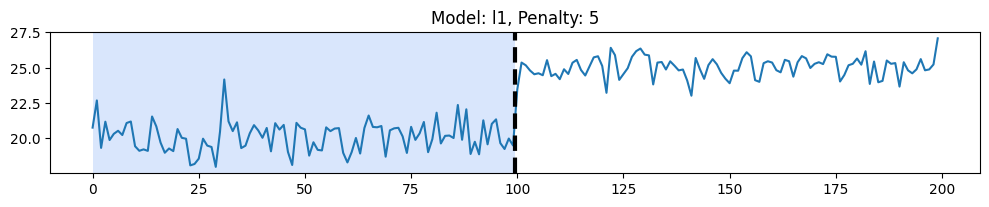

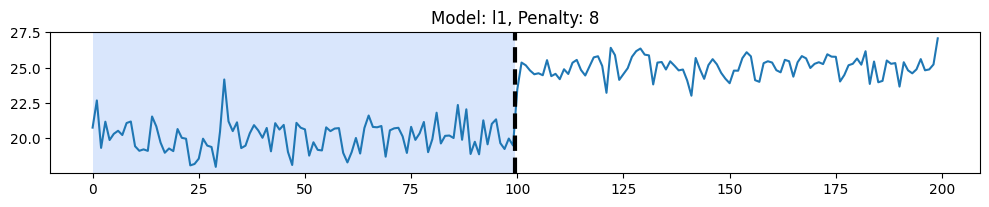

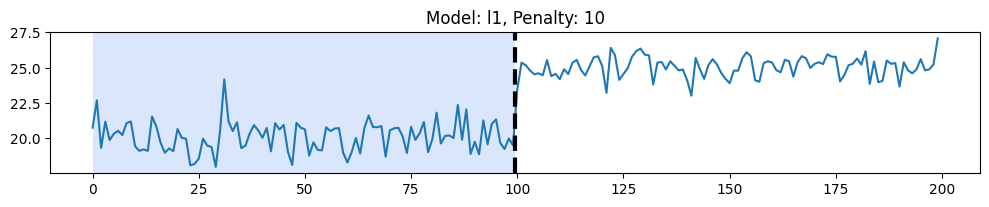

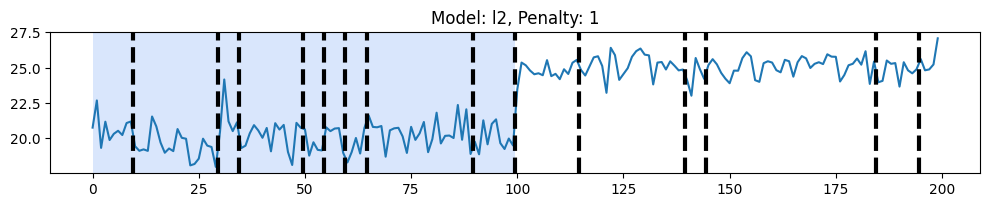

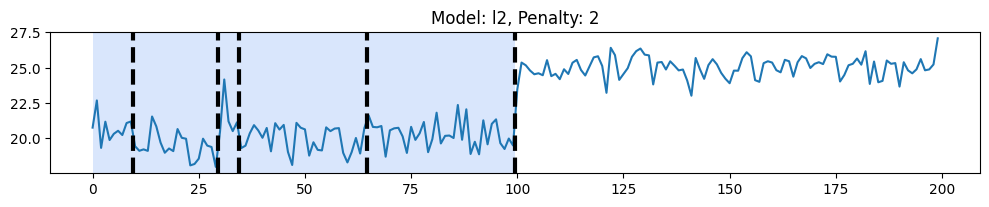

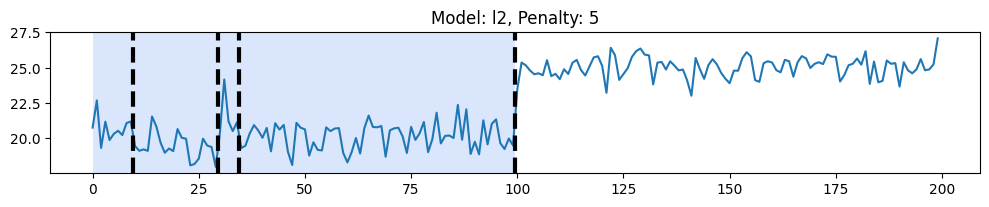

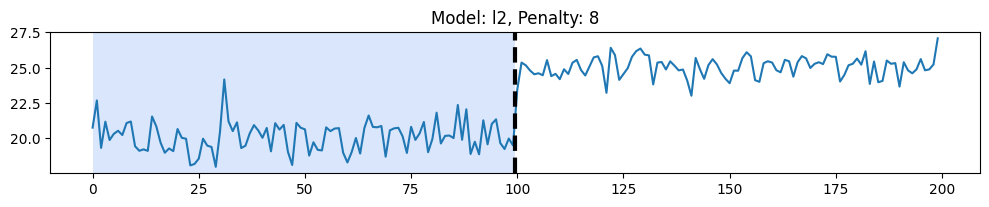

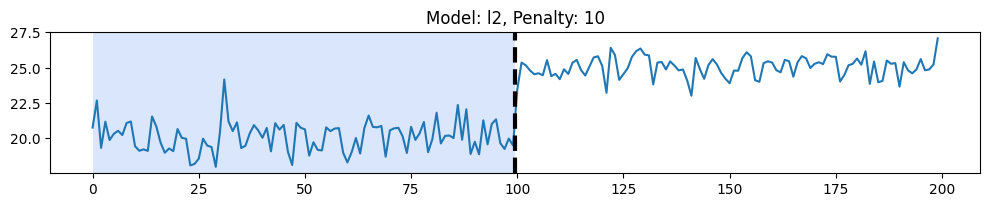

/usr/local/lib/python3.11/dist-packages/ruptures/costs/costnormal.py:27: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


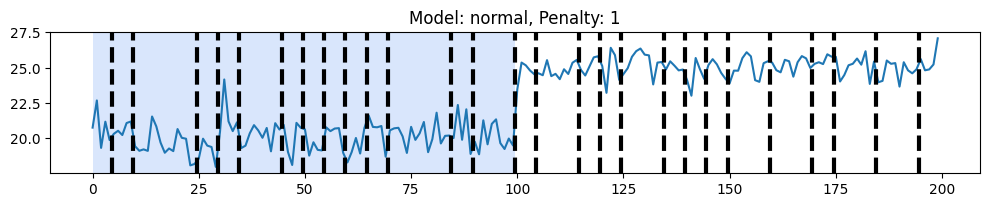

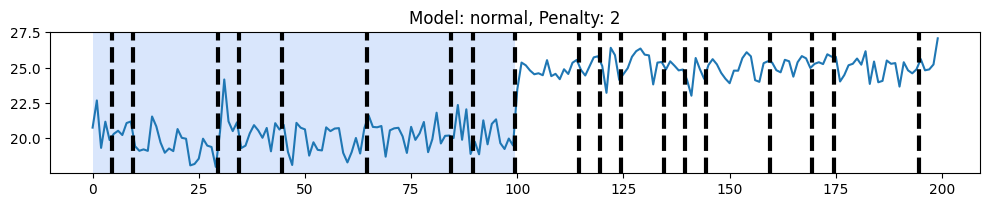

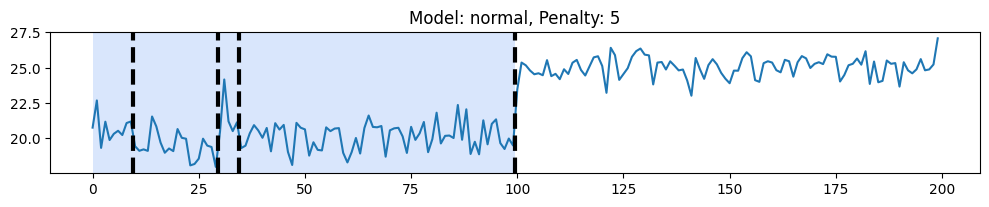

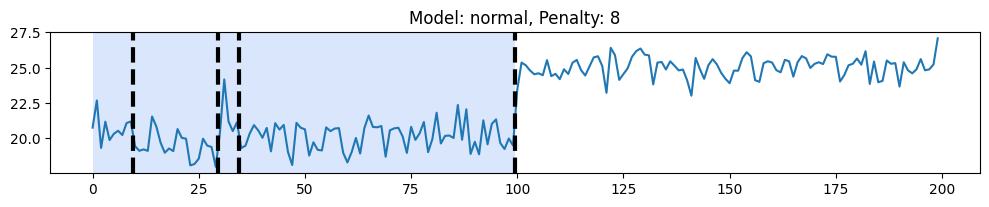

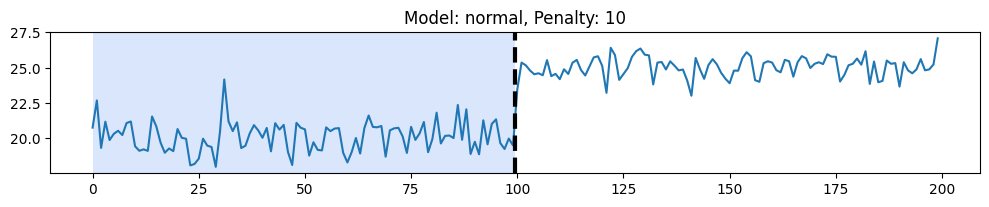

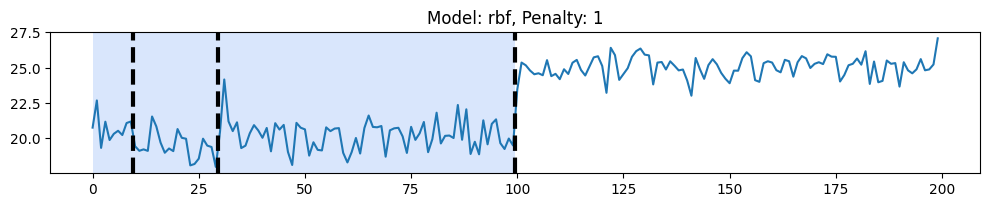

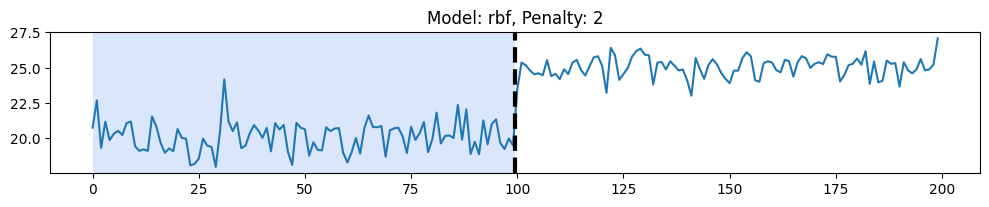

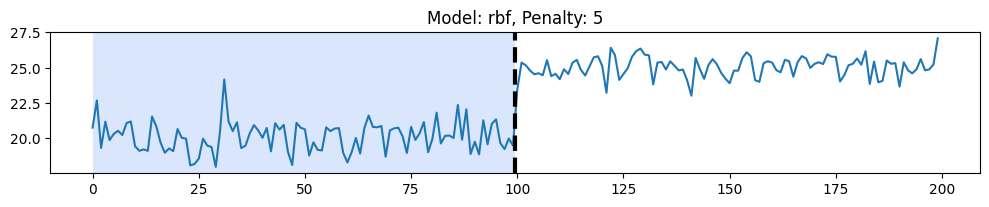

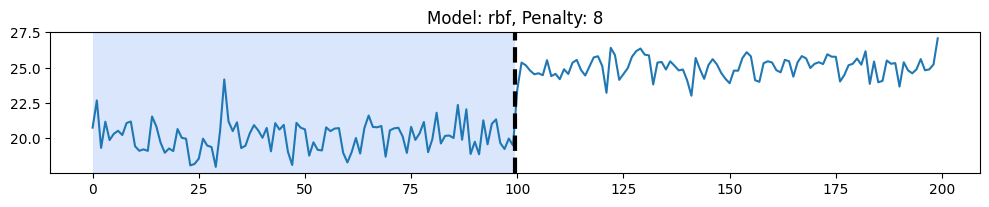

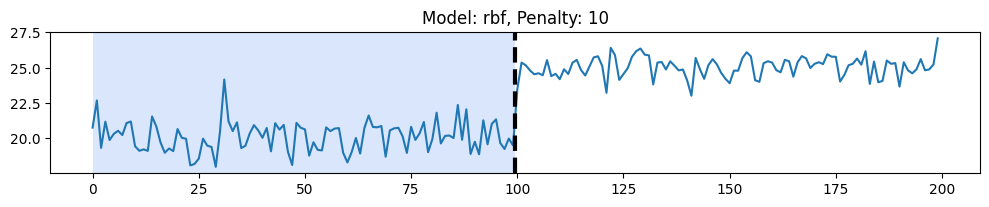

In [77]:
for model in ["l1", "l2", "normal", "rbf"]:
  for pen in [1, 2, 5, 8, 10]:
    #DETECTION
    algo = rpt.Pelt(model=model).fit(ym)
    result = algo.predict(pen=pen)

    # display
    rpt.display(ym, [100], result)
    title = f"Model: {model}, Penalty: {pen}"
    plt.title(title)
    pl.show()


Figure 6: Plot of prediction by the Pelt method with different model in the rupture package for the point of change in the ym dataset. All of The functions has predicted the POC almost perfectly.

# read in the data from LANL earthquake prediction

I saved ~~in the github repo~~ on my website (cause its too large for github regulra file and we did not talk about large file systems in github) as http://fbb.space/mltsa/LALNeq.csv.
This is a large file and will take a long time to read in. You cannot visualize the file in a browser via this link, but the link leads to automatic download (click the link again in the redirect page if you want to download the file in your machine, but you shoudl not need it because you can use pd.read_csv... to read it in directly). It is 1/100th of the original file. See how nice I am!?!

The original file was https://www.kaggle.com/c/LANL-Earthquake-Prediction/data

Visualize and use the method DataFrame.describe() to extract some basic statistics of the dataset

In [78]:
eq1 = pd.read_csv("http://fbb.space/mltsa/LALNeq.csv", index_col=0)

eq1.describe()

,acoustic_data,time_to_failure
count,4.500000e+06,4.500000e+06
mean,4.616407e+00,8.852012e-01
std,2.614006e+01,3.374432e-01
min,-4.621000e+03,3.008971e-01
25%,2.000000e+00,5.934956e-01
50%,5.000000e+00,8.849986e-01
75%,7.000000e+00,1.177597e+00
max,3.252000e+03,1.469100e+00


In [79]:
eq1.head()

,acoustic_data,time_to_failure
0,12,1.4691
1,6,1.4691
2,8,1.4691
3,5,1.4691
4,8,1.4691


# using rupture

Go through the documentation of rupture.

Find a method that takes as input the number of pocs and has computational complexity O(kN^2) and run it for k=1,2,3 pocs on the first N=10,000, 5000, and 1000 rows of the datasets respectively (make a plot for each and discuss each in the caption)




In [80]:
signal = eq1.acoustic_data.values

In [81]:
def detect_and_plot(signal, n_bkps, title):
    model = "normal"
    algo = rpt.Dynp(model=model).fit(signal)

    bkps = algo.predict(n_bkps=n_bkps)

    rpt.display(signal,[], bkps)
    plt.title(title)
    plt.show()

/usr/local/lib/python3.11/dist-packages/ruptures/costs/costnormal.py:27: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


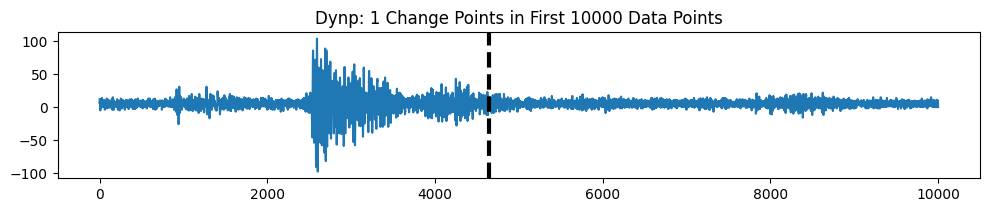

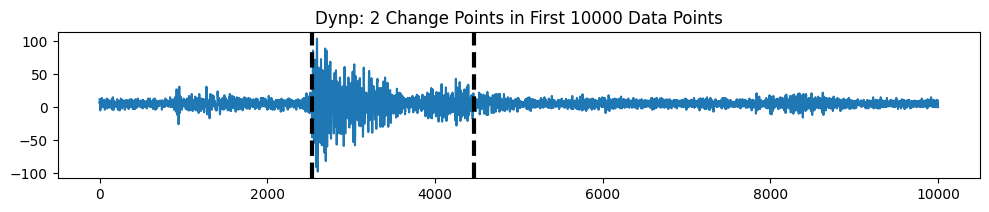

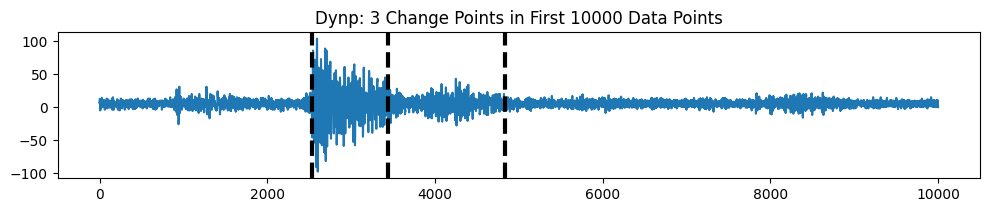

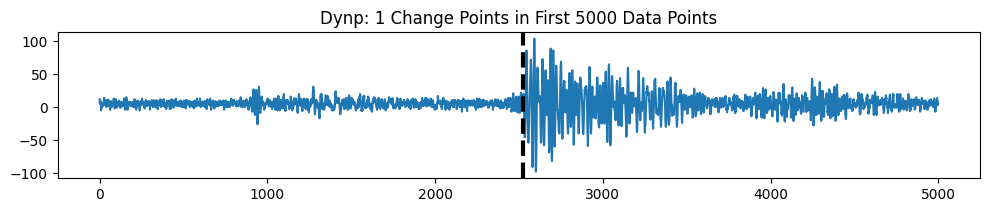

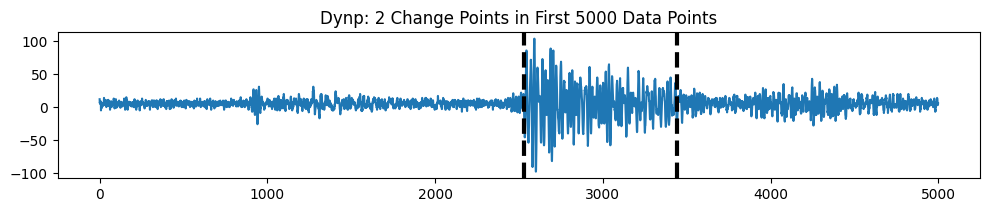

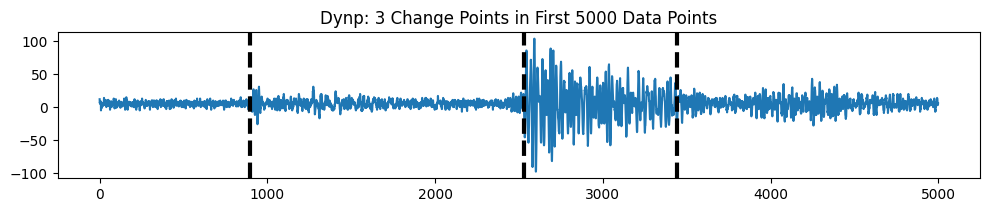

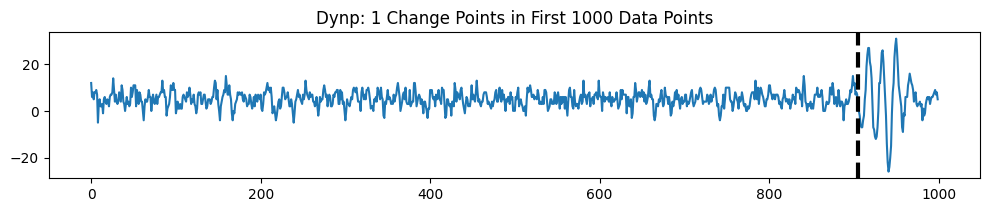

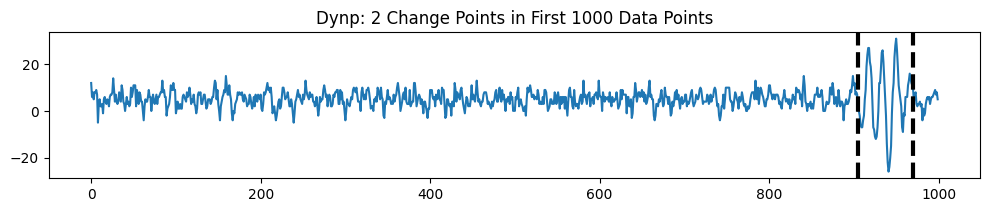

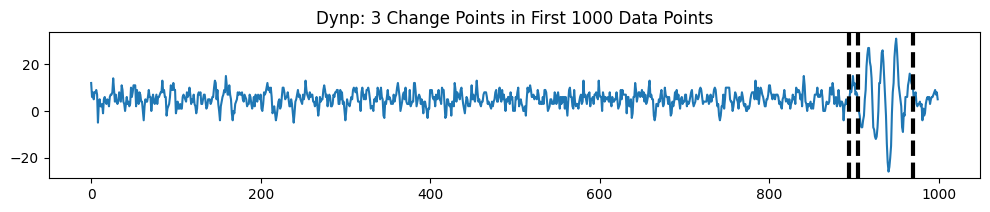

In [82]:
for N in [10000, 5000, 1000]:
  for k in [1, 2, 3]:
    sub_signal = signal[:N]
    title = f'Dynp: {k} Change Points in First {N} Data Points'
    detect_and_plot(sub_signal, n_bkps=k, title=title)

Figure 7: The plot above is the for the output of Dynp method with normal model for different k  and n values.

Find a method that has computational complexity O(Nlog(N))

Run both methods on the full 10000 rows dataset with the goal is to isolate 3 chunks of the time series. Read about the methods you choose, and describe the constraints you imposed and the paraemters you choose.

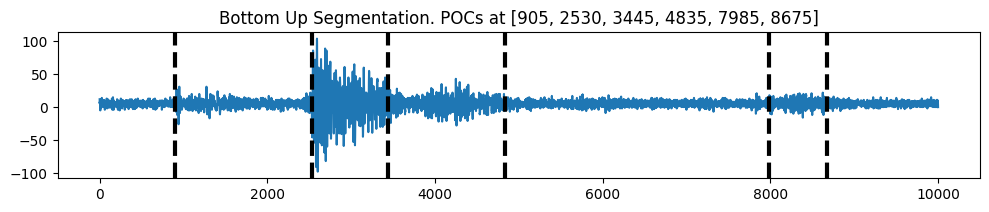

In [83]:
#Using Bottom Up Segmentation
N = 10000
algoA = rpt.BottomUp(model="normal").fit(eq1.acoustic_data.values[:N])
resultA = algoA.predict(n_bkps=6) #n_bkps: the number of change points

# display
rpt.display(eq1.acoustic_data.values[:N], [], resultA)
plt.title(f"Bottom Up Segmentation. POCs at {resultA[:-1]}")
plt.show()

Figure 8: The plot above is for output of perl algorithm (O(kN)) for k=6 and N=10000 with 'normal' model, first i was trying to use rbf but it was taking long time so changed to normal, i choose normal as it detect change in mean and variance both. it detected 6 POC as per i coded and accuracy is high.

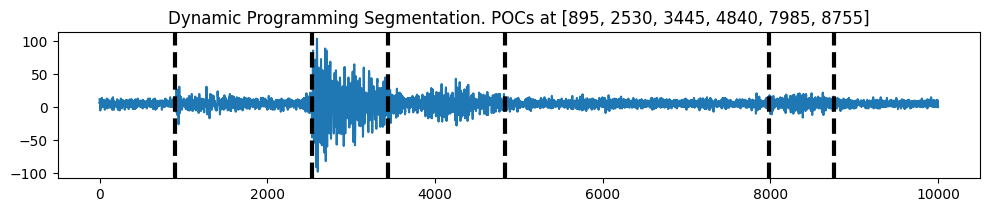

In [84]:
#Using Dynamic Programming
algoB = rpt.Dynp(model="normal").fit(eq1.acoustic_data.values[:N])
resultB = algoB.predict(n_bkps=6) #n_bkps: the number of change points

# display
rpt.display(eq1.acoustic_data.values[:N], [], resultB)
plt.title(f"Dynamic Programming Segmentation. POCs at {resultB[:-1]}")
plt.show()

Figure 9: The plot above is for output of Binary segmentation algorithm(O(Nlog(N))) for k=6 and N=10000, it is much faster then perl algorithm. As per theory it should be less accurate then perl but i feel for this data both worked nearly same.